# 🔬 Visualization Mini-Lab: Trends and Outliers

Now it’s time to put your skills to the test!
In this mini-lab, you’ll explore a real dataset, create visualizations, and identify **trends and outliers**.

We’ll use the famous **Penguins dataset** (thanks to Seaborn).

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 1. Explore Distributions

First, let’s look at the distribution of **body mass**.

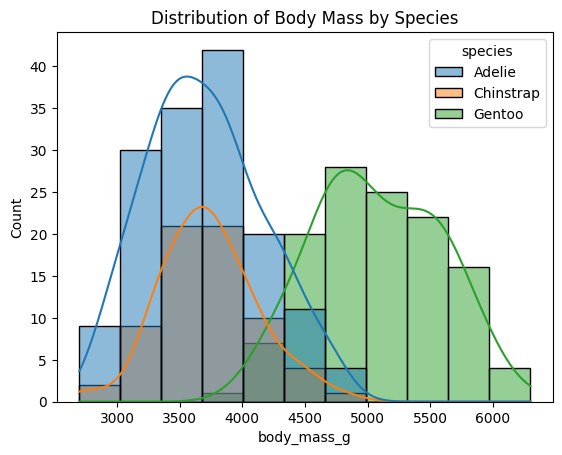

In [3]:
sns.histplot(data=penguins, x="body_mass_g", kde=True, hue="species")
plt.title("Distribution of Body Mass by Species")
plt.show()

👉 **Task:** Do some species have higher average body mass than others?

In [5]:
import seaborn as sns

# Load dataset
df = sns.load_dataset("penguins")

# Remove missing values in key columns
df = df.dropna(subset=["species", "body_mass_g"])

# Compute average body mass per species
avg_mass = df.groupby("species")["body_mass_g"].mean()

print(avg_mass)

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


## 2. Relationships Between Variables

Scatterplots help us see trends between two quantitative variables.

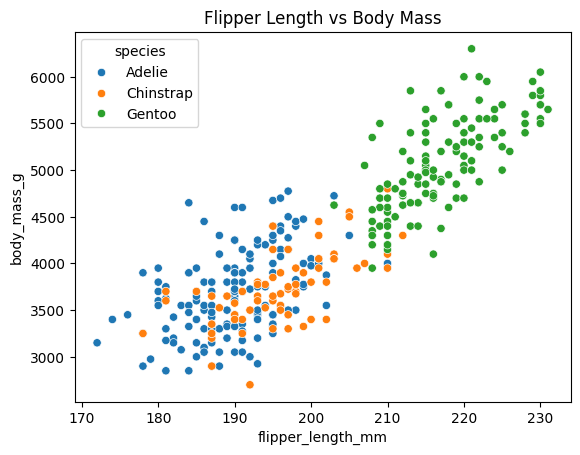

In [4]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species")
plt.title("Flipper Length vs Body Mass")
plt.show()

👉 **Task:** Which species tends to have longer flippers AND higher body mass?

In [6]:
import seaborn as sns

# Load dataset
df = sns.load_dataset("penguins")

# Remove missing values
df = df.dropna(subset=["species", "flipper_length_mm", "body_mass_g"])

# Group by species and compute averages
summary = df.groupby("species")[["flipper_length_mm", "body_mass_g"]].mean()

print(summary)

           flipper_length_mm  body_mass_g
species                                  
Adelie            189.953642  3700.662252
Chinstrap         195.823529  3733.088235
Gentoo            217.186992  5076.016260


## 3. Box Plots for Outliers

Box plots are great for spotting outliers.

C:\Users\Victoria Heredia\AppData\Local\Temp\ipykernel_34260\722458408.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x="species", y="bill_length_mm", palette="Set2")


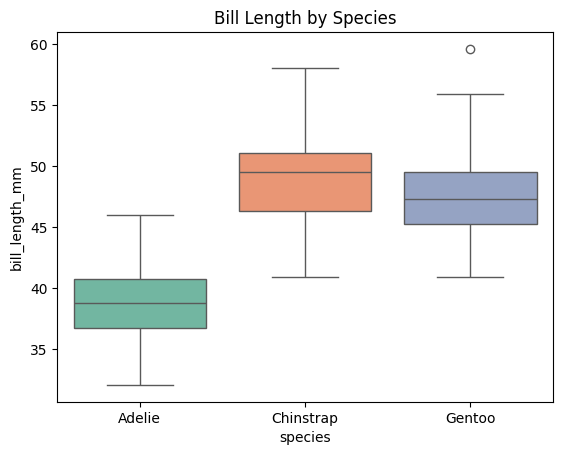

In [7]:
sns.boxplot(data=penguins, x="species", y="bill_length_mm", palette="Set2")
plt.title("Bill Length by Species")
plt.show()

👉 **Task:** Can you spot any outliers in the bill length data?

In [8]:
import seaborn as sns

# Load dataset
df = sns.load_dataset("penguins")

# Keep only valid values
df = df.dropna(subset=["bill_length_mm"])

# Compute Q1, Q3, and IQR
Q1 = df["bill_length_mm"].quantile(0.25)
Q3 = df["bill_length_mm"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df["bill_length_mm"] < lower_bound) | (df["bill_length_mm"] > upper_bound)]

print("Outliers in bill length:")
print(outliers[["species", "bill_length_mm"]])

Outliers in bill length:
Empty DataFrame
Columns: [species, bill_length_mm]
Index: []


## 4. Correlation Heatmap

Correlation heatmaps let us see overall variable relationships.

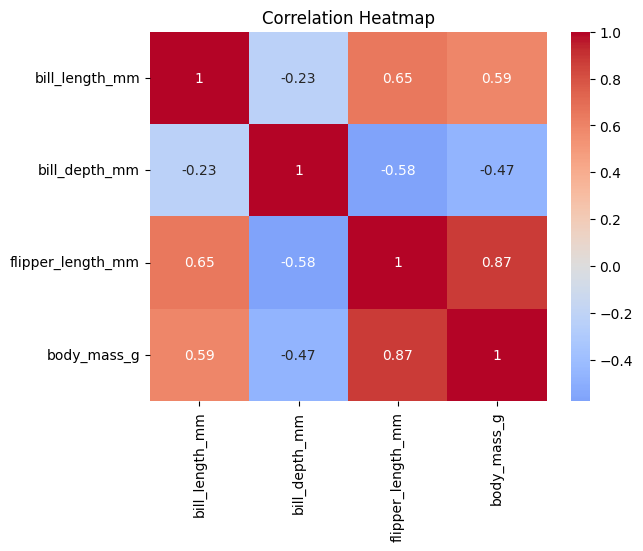

In [9]:
corr = penguins.dropna().corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

👉 **Task:** Which variables appear to be strongly correlated?

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


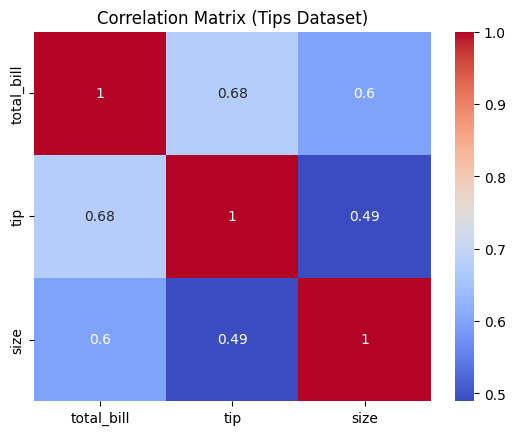

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("tips")

# Keep only numeric columns
num_df = df.select_dtypes(include="number")

# Correlation matrix
corr = num_df.corr()

print(corr)

# Heatmap to visualize correlations
plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Tips Dataset)")
plt.show()

## 5. Your Turn

- Try a different dataset (e.g., `tips`, `iris`).
- Create **at least 2 plots** that reveal a trend.
- Create **1 plot** that highlights possible outliers.
- Write a short summary of your findings.

> Remember: The goal is to **use visualizations to tell a story about the data.**

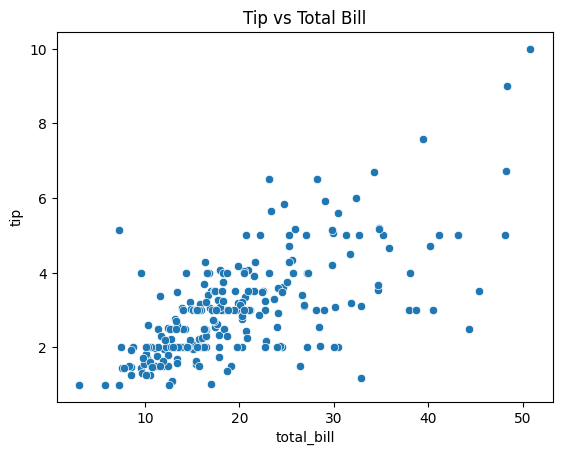

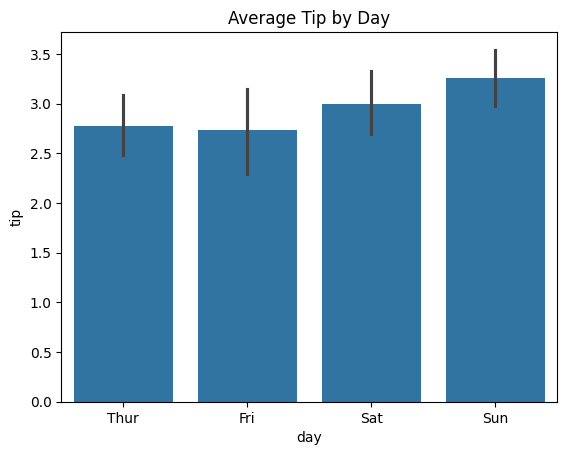

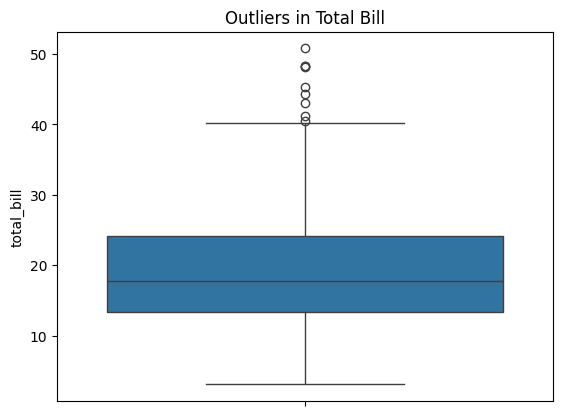

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("tips")

plt.figure()
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Tip vs Total Bill")
plt.show()

plt.figure()
sns.barplot(data=df, x="day", y="tip")
plt.title("Average Tip by Day")
plt.show()

plt.figure()
sns.boxplot(data=df, y="total_bill")
plt.title("Outliers in Total Bill")
plt.show()

---
✅ Congratulations! You’ve completed the visualization mini-lab and Week 07.

Next module → Working with larger datasets and diving deeper into analysis.